In [15]:
import pandas as pd
from allantools import Dataset, Plot
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

ncw = 1934050
def remove_outliers(data, zmax):
    data = np.asarray(data)
    median = np.median(data)
    stdev = np.std(data)
    zscores = (data-median) / stdev
    mask = np.abs(zscores) <=zmax
    return data[mask], mask


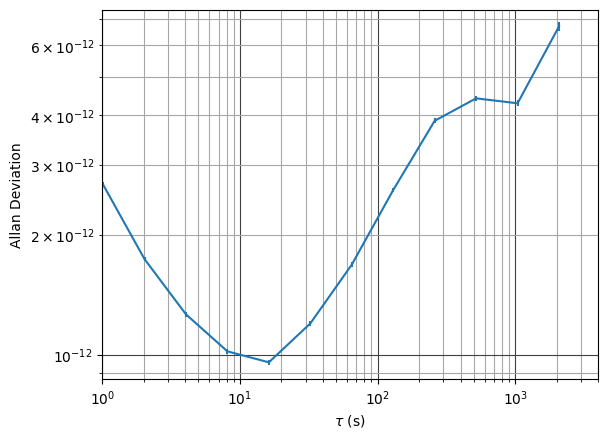

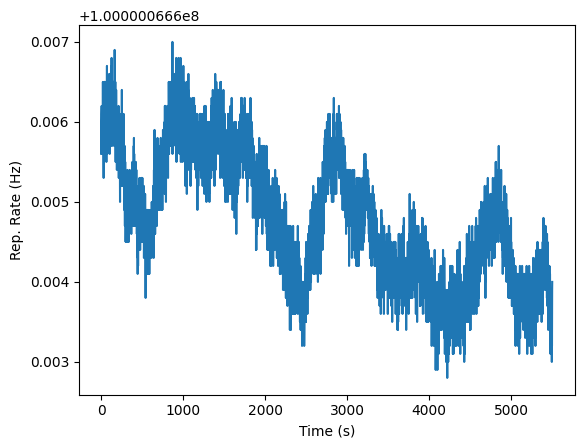

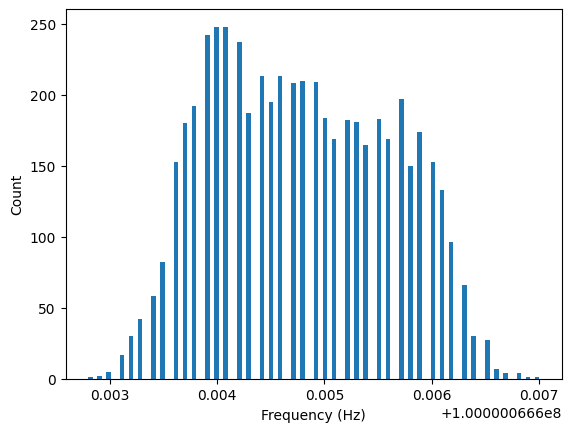

Standard deviation: 0.000821309462671648 Hz
2nd harmonic frequency uncertainty: 3176.9071325602013 Hz
3rd harmonic frequency uncertainty: 4765.360698840302 Hz
Mean: 100000066.58478539


In [ ]:
datafile = Path('/home/mike/Documents/Boulder_PhD/Data/11-24-25/counter2.txt')
df = pd.read_csv(datafile, delimiter='\t')
time_axis = df['Time (s)']
frequencies = df['Frequency (Hz)']

# remove unlock point
frequencies = frequencies[time_axis < 5500]
time_axis = time_axis[time_axis < 5500]

rate = 1/(time_axis[1]-time_axis[0])
adev_data = Dataset(data=frequencies/np.mean(frequencies), rate=rate, data_type='freq',taus='octave')
adev_data.compute('oadev')
# adev_data.write_results('adev.csv')

adev_plot = Plot()
adev_plot.plot(adev_data, errorbars=True, grid=True)
adev_plot.ax.set_xlabel(r'$\tau$ (s)')
adev_plot.ax.set_ylabel(r'Allan Deviation')
adev_plot.ax.set_xlim(1, 4000)
plt.show()

# w/ outliers
plt.plot(time_axis, frequencies)
plt.xlabel('Time (s)')
plt.ylabel('Rep. Rate (Hz)')
plt.show()

plt.hist(frequencies, bins=100)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
# plt.hist(freqs_no_outliers, bins=100)
plt.show()
print(f'Standard deviation: {np.std(frequencies)} Hz')
print(f'2nd harmonic frequency uncertainty: {np.std(frequencies)*2*ncw} Hz')
print(f'3rd harmonic frequency uncertainty: {np.std(frequencies)*3*ncw} Hz')
print(f'Mean: {np.mean(frequencies)}')

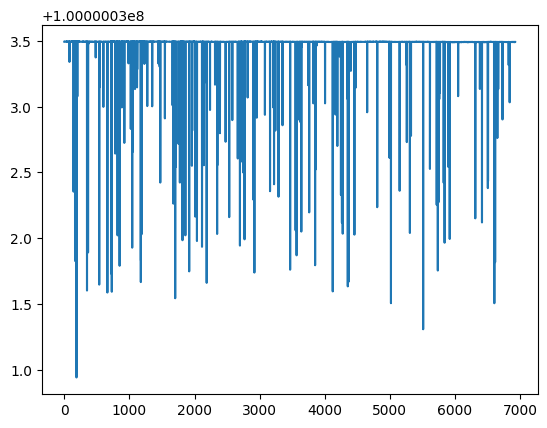

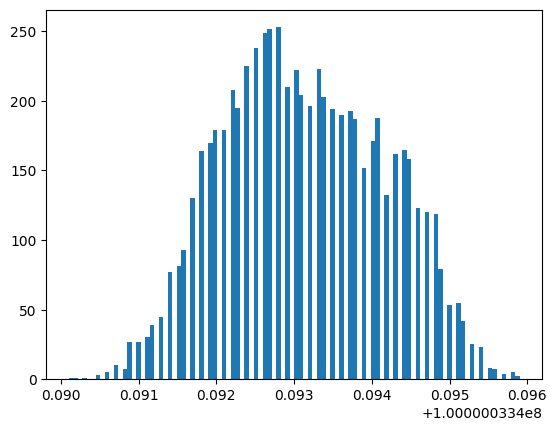

Standard deviation: 0.0010309222249324907 Hz
2nd harmonic frequency uncertainty: 3987.710258261367 Hz
3rd harmonic frequency uncertainty: 5981.565387392051 Hz
Mean: 100000033.47117904
Mean: 100000033.49312878


In [7]:
datafile = Path('/home/mike/Documents/Boulder_PhD/Data/11-24-25/counter1.txt')
df = pd.read_csv(datafile, delimiter='\t')
time_axis = df['Time (s)']
frequencies = df['Frequency (Hz)']

freqs_no_outliers = remove_outliers(frequencies, .05)

# w/ outliers
plt.plot(time_axis, frequencies)
plt.show()

# plt.hist(frequencies, bins=10000)
plt.hist(freqs_no_outliers, bins=100)
plt.show()
print(f'Standard deviation: {np.std(freqs_no_outliers)} Hz')
print(f'2nd harmonic frequency uncertainty: {np.std(freqs_no_outliers)*2*ncw} Hz')
print(f'3rd harmonic frequency uncertainty: {np.std(freqs_no_outliers)*3*ncw} Hz')
print(f'Mean: {np.mean(frequencies)}')
print(f'Mean: {np.mean(freqs_no_outliers)}')

# Estimating pressure broadening

In [8]:
from scipy.constants import atomic_mass as au
from scipy.constants import Boltzmann as k
import numpy as np

def pressure_torr(temp_K: float) -> float:
    if temp_K < 273+98:
        logp = 133.42927 - 9302.868 / temp_K + \
            0.03114431 * temp_K - 49.37679 * np.log10(temp_K)
    else:
        logp = 10.86423 - 5619.406 / temp_K + 0.00000345 * \
            temp_K - 1.04111  * np.log10(temp_K)
    return 10 ** logp


def number_density(temp_K: float) -> float:
    return 133.323 * pressure_torr(temp_K) / (k * temp_K)

d=166e-12
m=22.989 * au
T=400

n=number_density(T)
tbar = 1 / (n * d**2) * np.sqrt(m/ (16 * np.pi * k * T))
gamma = 2/tbar
print(pressure_torr(T))
print(n)
print(gamma)

1.2825205199662422e-06
3.096179464937491e+16
4.6014454002811


# Longer ADEV

[False False False ... False False False]
[ 700000.15126657  700001.16365981  700002.17236614 ... 1499997.38270879
 1499998.41052604 1499999.42040348]


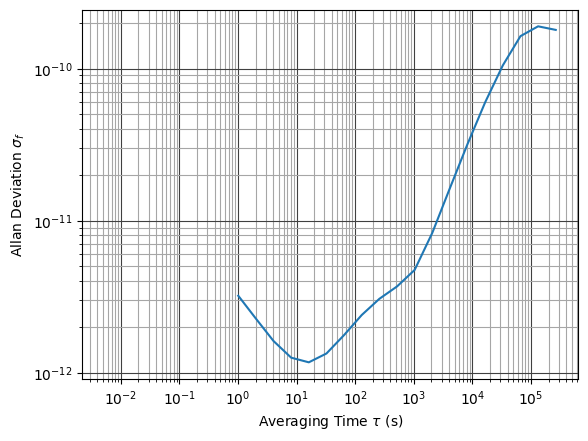

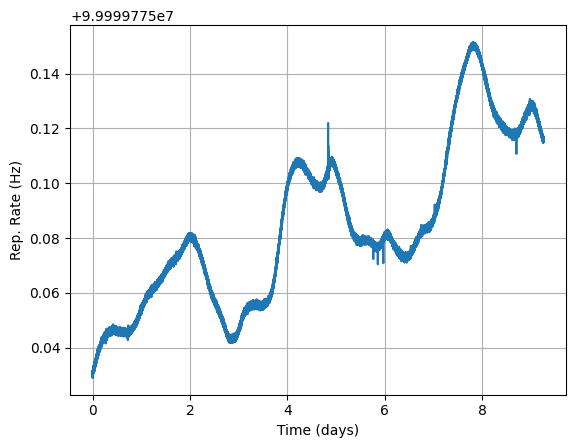

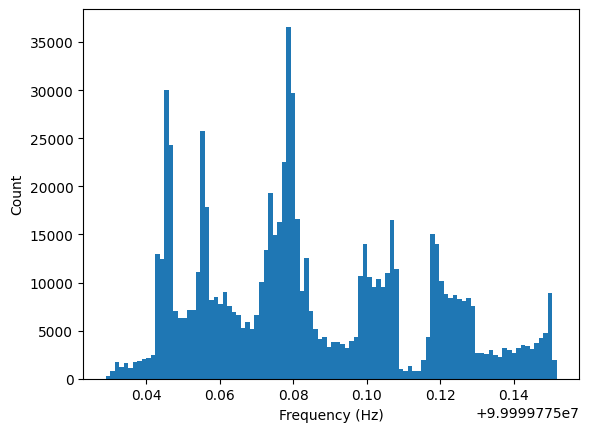

Standard deviation: 0.02973487885845173 Hz
2nd harmonic frequency uncertainty: 115017.48491237713 Hz
3rd harmonic frequency uncertainty: 172526.22736856568 Hz
Mean: 99999775.08456925


In [18]:
# datafile = Path('/home/mike/Documents/Boulder_PhD/Data/1-14-2026/leo_fr.txt')
datafile = Path('leo_fr_long.txt')
df = pd.read_csv(datafile, delimiter='\t')
time_axis = df['Time (s)'].to_numpy()
frequencies = df['Frequency (Hz)'].to_numpy()
mask = (time_axis > .7e6) & (time_axis <1.5e6)
print(mask)
time_axis=time_axis[mask]
print(time_axis)
frequencies=frequencies[mask]
frequencies, outlier_mask = remove_outliers(frequencies, 1)
time_axis=time_axis[outlier_mask]

rate = 1/(time_axis[1]-time_axis[0])
adev_data = Dataset(data=frequencies/np.mean(frequencies), rate=rate, data_type='freq',taus='octave')
adev_data.compute('oadev')
# adev_data.write_results('adev.csv')

adev_plot = Plot()
adev_plot.plot(adev_data, errorbars=True, grid=True)
adev_plot.ax.set_xlabel(r'Averaging Time $\tau$ (s)')
adev_plot.ax.set_ylabel(r'Allan Deviation $\sigma_f$')
# adev_plot.ax.set_xlim(1, 10000)
plt.show()

time_days = time_axis/60/60/24
time_days = time_days - time_days[0]
plt.plot(time_days, frequencies)
plt.xlabel('Time (days)')
plt.ylabel('Rep. Rate (Hz)')
plt.grid()
plt.show()

plt.hist(frequencies, bins=100)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
# plt.hist(freqs_no_outliers, bins=100)
plt.show()
print(f'Standard deviation: {np.std(frequencies)} Hz')
print(f'2nd harmonic frequency uncertainty: {np.std(frequencies)*2*ncw} Hz')
print(f'3rd harmonic frequency uncertainty: {np.std(frequencies)*3*ncw} Hz')
print(f'Mean: {np.mean(frequencies)}')

[ True  True  True ... False False False]
[2.38418579e-07 1.01147580e+00 2.02129316e+00 ... 5.99997133e+05
 5.99998141e+05 5.99999150e+05]


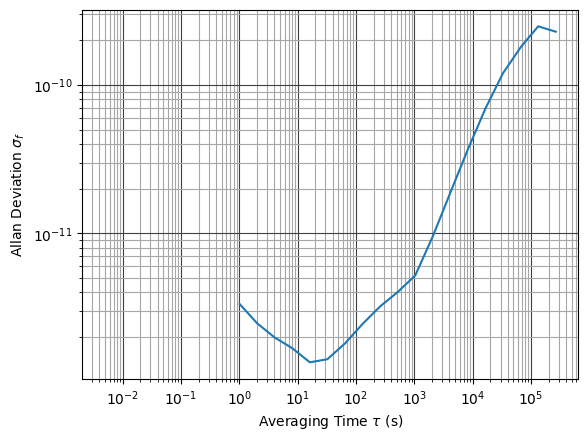

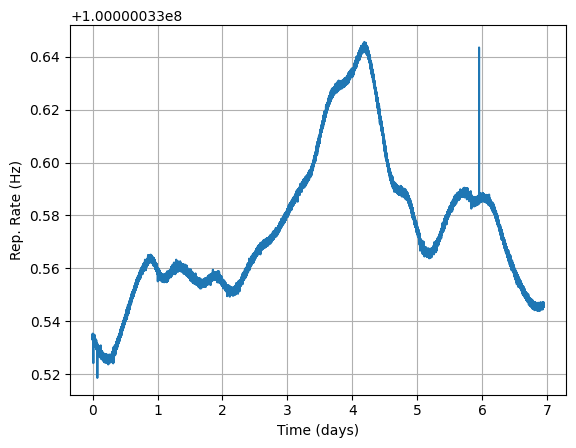

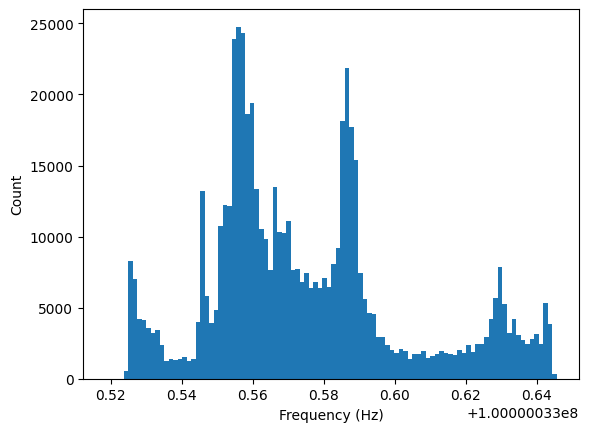

Standard deviation: 0.02813527677944119 Hz
2nd harmonic frequency uncertainty: 108830.06411055647 Hz
3rd harmonic frequency uncertainty: 163245.0961658347 Hz
Mean: 100000033.5752337


In [22]:
# datafile = Path('/home/mike/Documents/Boulder_PhD/Data/1-14-2026/leo_fr.txt')
datafile = Path('leo_fr_long.txt')
df = pd.read_csv(datafile, delimiter='\t')
time_axis = df['Time (s)'].to_numpy()
frequencies = df['Frequency (Hz)'].to_numpy()
mask = (time_axis < .6e6)
print(mask)
time_axis=time_axis[mask]
print(time_axis)
frequencies=frequencies[mask]
frequencies, outlier_mask = remove_outliers(frequencies, 1)
time_axis=time_axis[outlier_mask]

rate = 1/(time_axis[1]-time_axis[0])
adev_data = Dataset(data=frequencies/np.mean(frequencies), rate=rate, data_type='freq',taus='octave')
adev_data.compute('oadev')
# adev_data.write_results('adev.csv')

adev_plot = Plot()
adev_plot.plot(adev_data, errorbars=True, grid=True)
adev_plot.ax.set_xlabel(r'Averaging Time $\tau$ (s)')
adev_plot.ax.set_ylabel(r'Allan Deviation $\sigma_f$')
# adev_plot.ax.set_xlim(1, 10000)
plt.show()

time_days = time_axis/60/60/24
time_days = time_days - time_days[0]
plt.plot(time_days, frequencies)
plt.xlabel('Time (days)')
plt.ylabel('Rep. Rate (Hz)')
plt.grid()
plt.show()

plt.hist(frequencies, bins=100)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
# plt.hist(freqs_no_outliers, bins=100)
plt.show()
print(f'Standard deviation: {np.std(frequencies)} Hz')
print(f'2nd harmonic frequency uncertainty: {np.std(frequencies)*2*ncw} Hz')
print(f'3rd harmonic frequency uncertainty: {np.std(frequencies)*3*ncw} Hz')
print(f'Mean: {np.mean(frequencies)}')

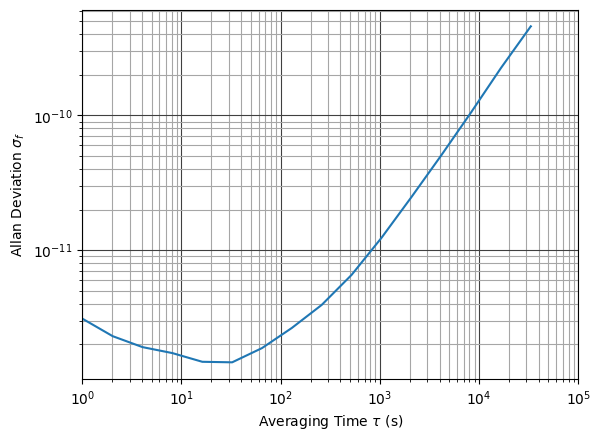

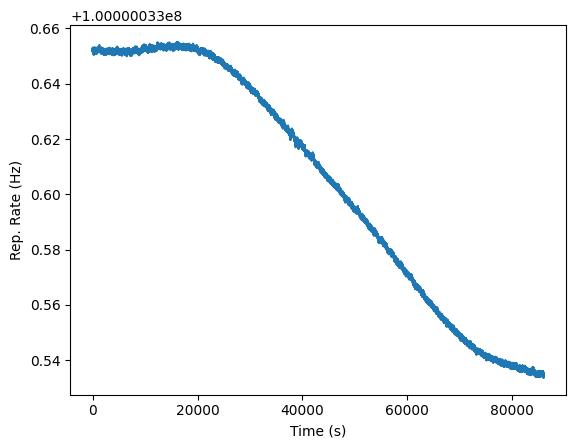

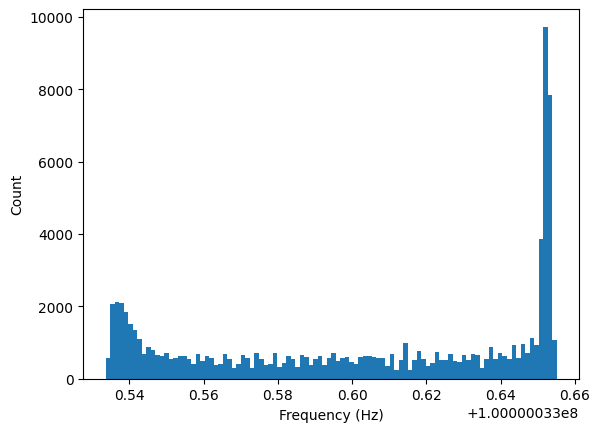

Standard deviation: 0.04350205123990538 Hz
2nd harmonic frequency uncertainty: 168270.284401078 Hz
3rd harmonic frequency uncertainty: 252405.426601617 Hz
Mean: 100000033.60372101


In [34]:
datafile = Path('/home/mike/Documents/Boulder_PhD/Data/1-15-2026/leo_fr_80k.txt')
df = pd.read_csv(datafile, delimiter='\t')
time_axis = df['Time (s)']
frequencies = df['Frequency (Hz)']
frequencies = remove_outliers(frequencies, 1)

rate = 1/(time_axis[1]-time_axis[0])
adev_data = Dataset(data=frequencies/np.mean(frequencies), rate=rate, data_type='freq',taus='octave')
adev_data.compute('oadev')
# adev_data.write_results('adev.csv')

adev_plot = Plot()
adev_plot.plot(adev_data, errorbars=True, grid=True)
adev_plot.ax.set_xlabel(r'Averaging Time $\tau$ (s)')
adev_plot.ax.set_ylabel(r'Allan Deviation $\sigma_f$')
adev_plot.ax.set_xlim(1, 100000)
plt.show()

# w/ outliers
plt.plot(frequencies)
plt.xlabel('Time (s)')
plt.ylabel('Rep. Rate (Hz)')
plt.show()

plt.hist(frequencies, bins=100)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Count')
# plt.hist(freqs_no_outliers, bins=100)
plt.show()
print(f'Standard deviation: {np.std(frequencies)} Hz')
print(f'2nd harmonic frequency uncertainty: {np.std(frequencies)*2*ncw} Hz')
print(f'3rd harmonic frequency uncertainty: {np.std(frequencies)*3*ncw} Hz')
print(f'Mean: {np.mean(frequencies)}')